In [2]:
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv
import signature.tensor_algebra as ta
from simulation.diffusion import Diffusion

my_green = "#5b6c64"
my_copper = "#B56246"
color_cycle = [my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"]
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=color_cycle)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
n_t_grid = 10_001
t_grid = np.linspace(0, 2, n_t_grid)
cp_idx = n_t_grid // 2

rng = np.random.default_rng(seed=42)
diffusion = Diffusion(t_grid=t_grid, size=1, dim=1, rng=rng)

mu_1 = 500
mu_2 = 50

sigma_1 = np.sqrt(2 * mu_1)
sigma_2 = np.sqrt(2 * mu_2)

ou_1 = diffusion.ornstein_uhlenbeck(lam=mu_1, sigma=sigma_1, squeeze=True)
ou_2 = diffusion.ornstein_uhlenbeck(lam=mu_2, sigma=sigma_2, squeeze=True)

signal = np.zeros_like(ou_1)
signal[:cp_idx] = ou_1[:cp_idx]
signal[cp_idx:] = ou_2[cp_idx:] + np.exp(-mu_2 * (t_grid[cp_idx:] - t_grid[cp_idx - 1])) * (ou_1[cp_idx - 1] - ou_2[cp_idx - 1])

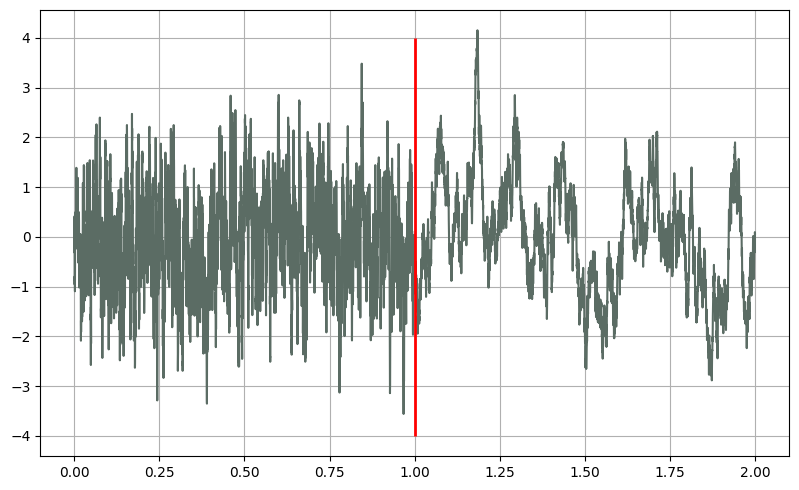

In [37]:
fig, ax = plt.subplots()

ax.plot(t_grid, signal)
ax.vlines(t_grid[cp_idx], ymin=-4, ymax=4, linestyles='-', color="r", lw=2)

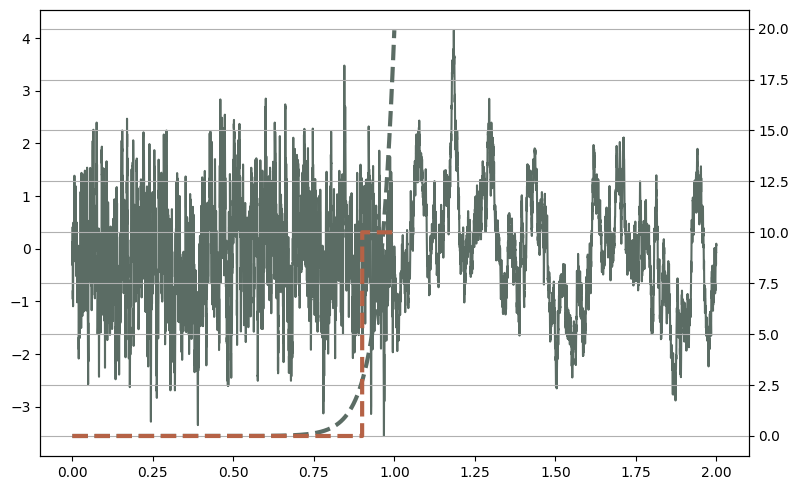

In [38]:
fig, ax = plt.subplots()
# 1. Create the twin axis for the exponential curves
ax_twin = ax.twinx()

# 2. Plot the signals on the original (left) y-axis
line1, = ax.plot(t_grid, signal, color=color_cycle[0], label='Signal')

# 3. Plot the exponential curves on the new (right) y-axis
# Added linestyle='--' to help distinguish theoretical curves from raw data
lam_1 = 20
line3, = ax_twin.plot(t_grid[:cp_idx], lam_1 * np.exp(lam_1 * (t_grid[:cp_idx] - t_grid[cp_idx])),
                     color=color_cycle[0], linestyle='--', label='Fit 1', lw=3)
wind = 500 / 5000
line3, = ax_twin.plot(t_grid[:cp_idx], (t_grid[:cp_idx] <= 1) * (t_grid[:cp_idx] >= 1 - wind) / wind,
                     color=color_cycle[1], linestyle='--', label='Fit 1', lw=3)
ax.grid(False)

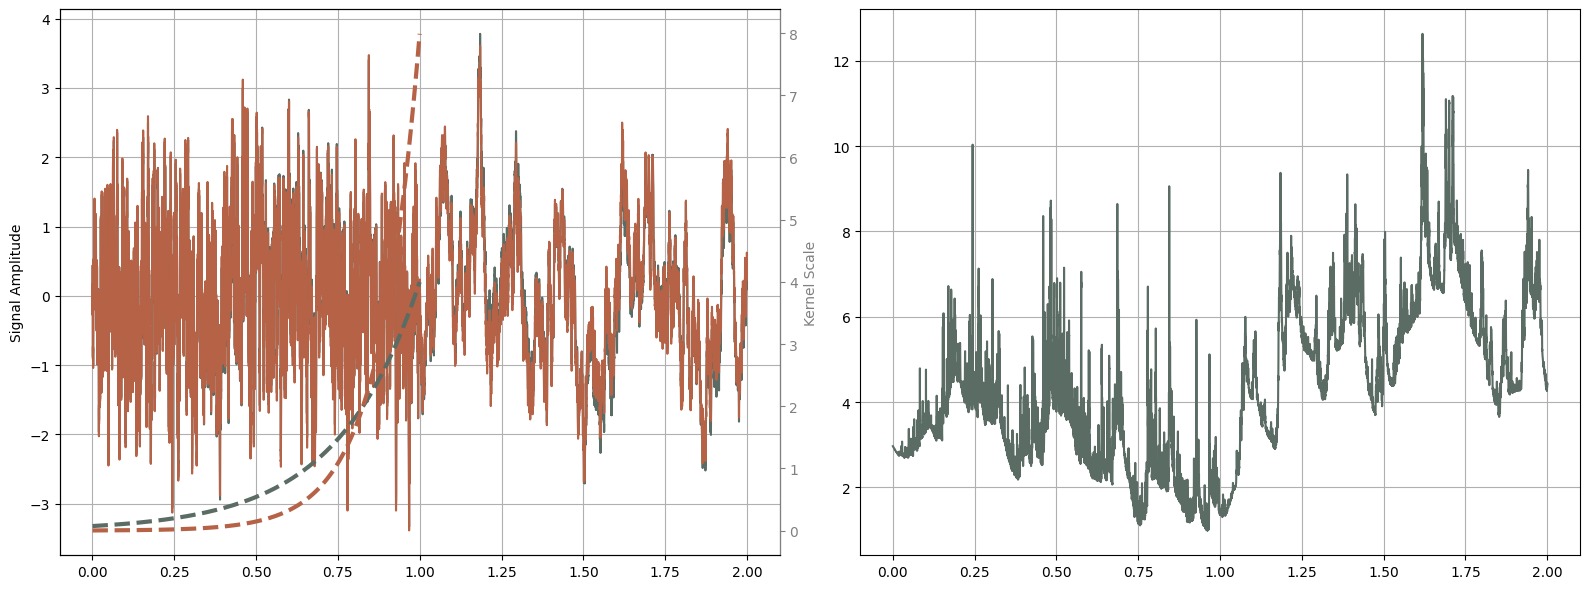

In [39]:
# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
path = np.vstack((t_grid, t_grid, signal)).T

trunc = 5

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

lam_1 = 4
path_1 = path.copy()
path_1[:, 1:] = path_1[:, 1:] * lam_1
transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])


efm_sig_1 = pipe_1.fit_transform(path_1)

lam_2 = 8
path_2 = path.copy()
path_2[:, 1:] = path_2[:, 1:] * lam_2
transformer_2 = EFMSignatureTransform(trunc=trunc, lam=lam_2)
pipe_2 = Pipeline([
    ('sig',transformer_2),
    ('scaler', StandardScaler()),
])

efm_sig_2 = pipe_2.fit_transform(path_2)

sig_idx = ta.word_to_index(word=2, dim=2)

# ax[0].plot(t_grid, efm_sig_1[:, sig_idx], color=color_cycle[0])
# ax[0].plot(t_grid, efm_sig_2[:, sig_idx], color=color_cycle[1])
# ax[0].plot(t_grid[:cp_idx], lam_1 * np.exp(lam_1 * (t_grid[:cp_idx] - t_grid[cp_idx])), color=color_cycle[0])
# ax[0].plot(t_grid[:cp_idx], lam_2 * np.exp(lam_2 * (t_grid[:cp_idx] - t_grid[cp_idx])), color=color_cycle[1])

# 1. Create the twin axis for the exponential curves
ax_twin = ax[0].twinx()

# 2. Plot the signals on the original (left) y-axis
line1, = ax[0].plot(t_grid, efm_sig_1[:, sig_idx], color=color_cycle[0], label='Signal 1')
line2, = ax[0].plot(t_grid, efm_sig_2[:, sig_idx], color=color_cycle[1], label='Signal 2')

# 3. Plot the exponential curves on the new (right) y-axis
# Added linestyle='--' to help distinguish theoretical curves from raw data
line3, = ax_twin.plot(t_grid[:cp_idx], lam_1 * np.exp(lam_1 * (t_grid[:cp_idx] - t_grid[cp_idx])),
                     color=color_cycle[0], linestyle='--', label='Fit 1', lw=3)
line4, = ax_twin.plot(t_grid[:cp_idx], lam_2 * np.exp(lam_2 * (t_grid[:cp_idx] - t_grid[cp_idx])),
                     color=color_cycle[1], linestyle='--', label='Fit 2', lw=3)

# 4. Optional: Label the axes to avoid confusion
ax[0].set_ylabel('Signal Amplitude')
ax_twin.set_ylabel('Kernel Scale')

# 5. Optional: Coloring the axis ticks/labels to match the data can be helpful
ax_twin.spines['right'].set_color('gray')
ax_twin.tick_params(axis='y', colors='gray')
ax_twin.yaxis.label.set_color('gray')
ax_twin.grid(False)

ax[1].plot(t_grid, np.sqrt(np.sum((efm_sig_1 - efm_sig_2)**2, axis=1)))
# ax[1].set_ylim([0, 100000000])

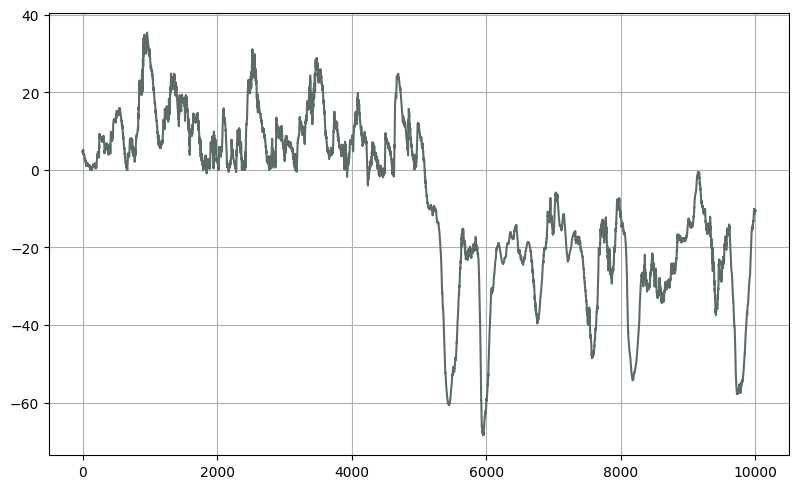

In [40]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
path = np.vstack((t_grid, t_grid, signal)).T

trunc = 5

lam_1 = 20
path_1 = path.copy()
path_1[:, 1:] = path_1[:, 1:] * lam_1
transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
model.fit(X=efm_sig_1[:cp_idx - 1000])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score = model.decision_function(new_S_t)

plt.plot(regime_score)

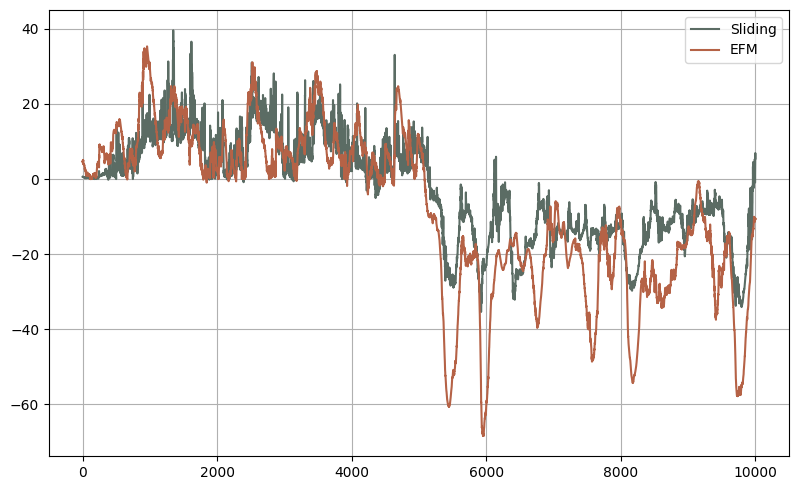

In [41]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
path = np.vstack((t_grid, signal)).T

trunc = 5

window_size = 500
path_1 = path.copy()
transformer_1 = RollingSignatureTransform(trunc=trunc, window_size=window_size)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
model.fit(X=efm_sig_1[:cp_idx - 1000])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score_sliding = model.decision_function(new_S_t)

plt.plot(regime_score_sliding, label="Sliding")
plt.plot(regime_score, label="EFM")
plt.legend()


In [77]:
df = pd.read_excel("data/EEX_TTF.xlsx", index_col=0)
df.rename(
    columns={
        "TTF_FUTURE_CALENDAR_PRICE C+1 (EUR/MWh)": "C+1",
        "TTF_FUTURE_CALENDAR_PRICE C+2 (EUR/MWh)": "C+2",
        "TTF_FUTURE_CALENDAR_PRICE C+3 (EUR/MWh)": "C+3",
        "TTF_FUTURE_MONTH_PRICE M+1 (EUR/MWh)": "M+1",
        "TTF_FUTURE_MONTH_PRICE M+2 (EUR/MWh)": "M+2",
        "TTF_FUTURE_MONTH_PRICE M+3 (EUR/MWh)": "M+3",
        "TTF_FUTURE_QUARTER_PRICE Q+1 (EUR/MWh)": "Q+1",
        "TTF_FUTURE_QUARTER_PRICE Q+2 (EUR/MWh)": "Q+2",
        "TTF_FUTURE_QUARTER_PRICE Q+3 (EUR/MWh)": "Q+3",
        "TTF_FUTURE_SEASON_PRICE S+1 (EUR/MWh)": "S+1",
        "TTF_FUTURE_SEASON_PRICE S+2 (EUR/MWh)": "S+2",
    },
    inplace=True
)
df.index = df.index.normalize()
df = df.dropna()

# List of dates to remove (arbitrage)
unwanted_dates = ['2022-03-30', '2022-03-31', '2024-12-31', '2024-12-30', '2021-12-31', '2021-12-30']
# Keep rows where the date is NOT in the unwanted list
df = df[~df.index.isin(unwanted_dates)]

index = df.index
t_grid = np.array((index - index[0]).days / 365)

signal = np.array(df["M+1"]) - np.array(df["C+1"])

In [78]:
signal.shape

(3286,)

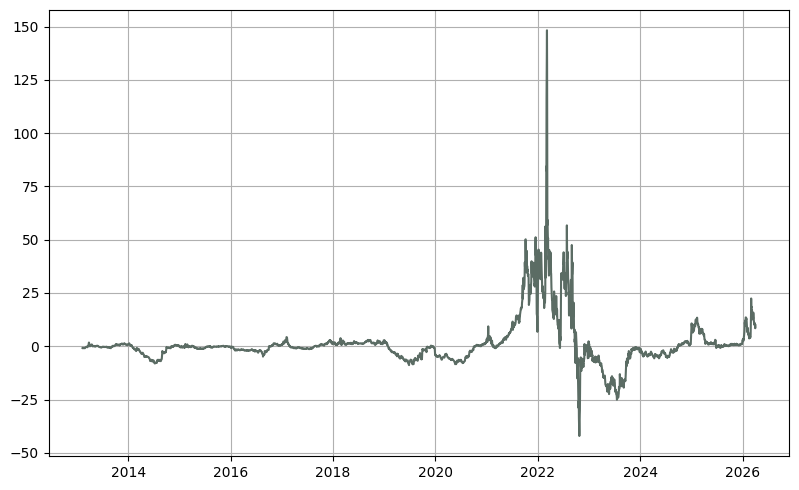

In [79]:
plt.plot(index, signal)

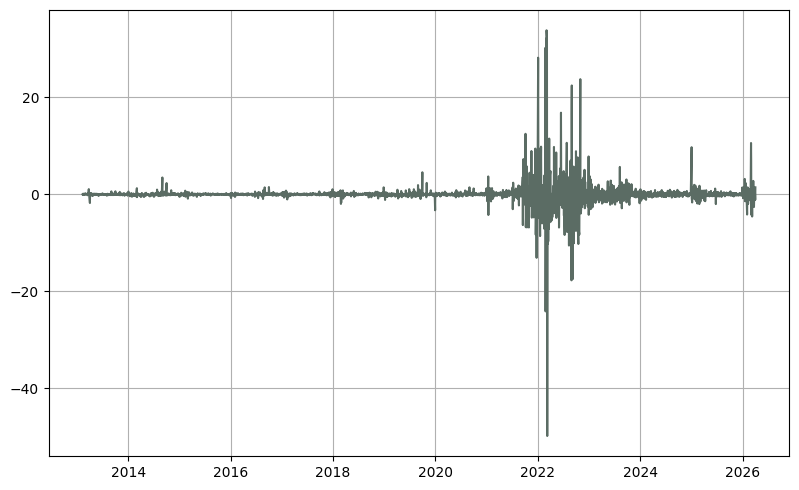

In [66]:
plt.plot(index, np.diff(signal, prepend=signal[0:1]))

(3286,) (3286,)


(-1.0, 1.0)

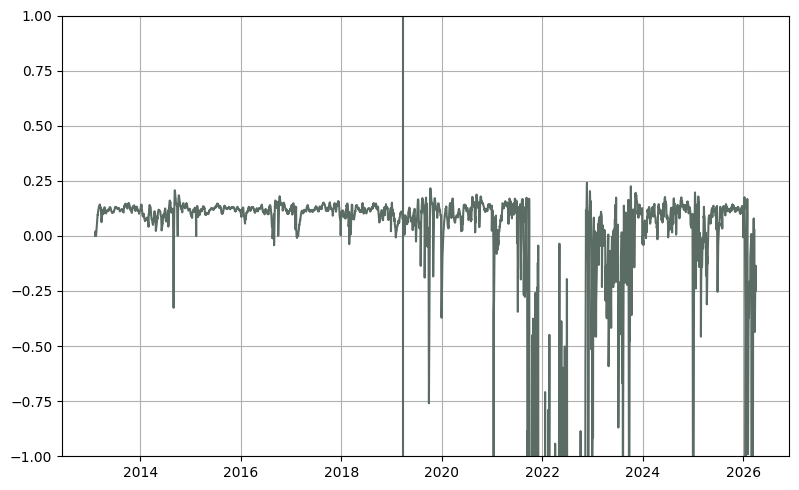

In [72]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
print(t_grid.shape, signal.shape)
path = np.vstack((t_grid, t_grid, signal)).T

trunc = 5
N_train = 1500
lam_1 = 70
path_1 = path.copy()
path_1[:, 1:] = path_1[:, 1:] * lam_1
transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
model.fit(X=efm_sig_1[:N_train])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score = model.decision_function(new_S_t)

plt.plot(index, regime_score)
plt.vlines(index[N_train], -50, 50, label="EFM")
plt.ylim([-1, 1])

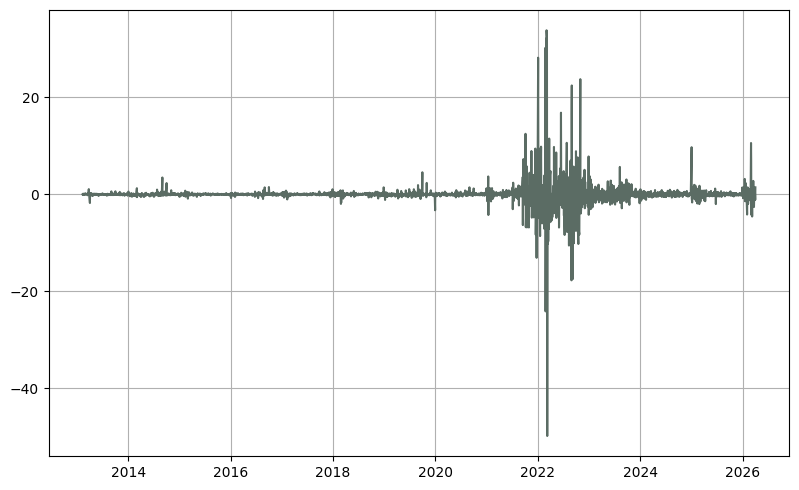

In [73]:
plt.plot(index, np.diff(signal, prepend=signal[0:1]))

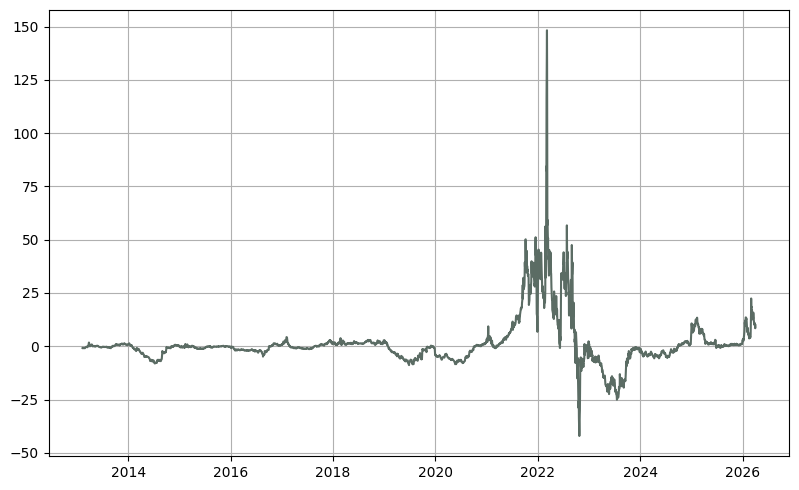

In [68]:
plt.plot(index, signal)

## Regime change in stochastic volatility models

In [80]:
from pricing.models.heston import Heston

In [96]:
stoch_vol_model_before = Heston(theta=0.057, rho=-0.7, lam=2.15, nu=0.86, V0=0.023)

In [263]:
T = 20
N_points = 250 * T
t_grid_before = np.linspace(0, T, N_points)
t_grid_after = np.linspace(T, 2 * T, N_points)

rng = np.random.default_rng(seed=40)
S_before, V_before = stoch_vol_model_before.get_price_trajectory(t_grid=t_grid_before, size=1, F0=100, rng=rng, return_variance=True)
S_before = S_before.squeeze()
V_before = V_before.squeeze()

stoch_vol_model_after = Heston(theta=0.1, rho=-0.4, lam=10, nu=1.5, V0=V_before[-1])
S_after, V_after = stoch_vol_model_after.get_price_trajectory(t_grid=t_grid_after, size=1, F0=S_before[-1], rng=rng, return_variance=True)
S_after = S_after.squeeze()
V_after = V_after.squeeze()

S = np.concatenate([S_before, S_after[1:]])
V = np.concatenate([V_before, V_after[1:]])
t_grid = np.concatenate([t_grid_before, t_grid_after[1:]])

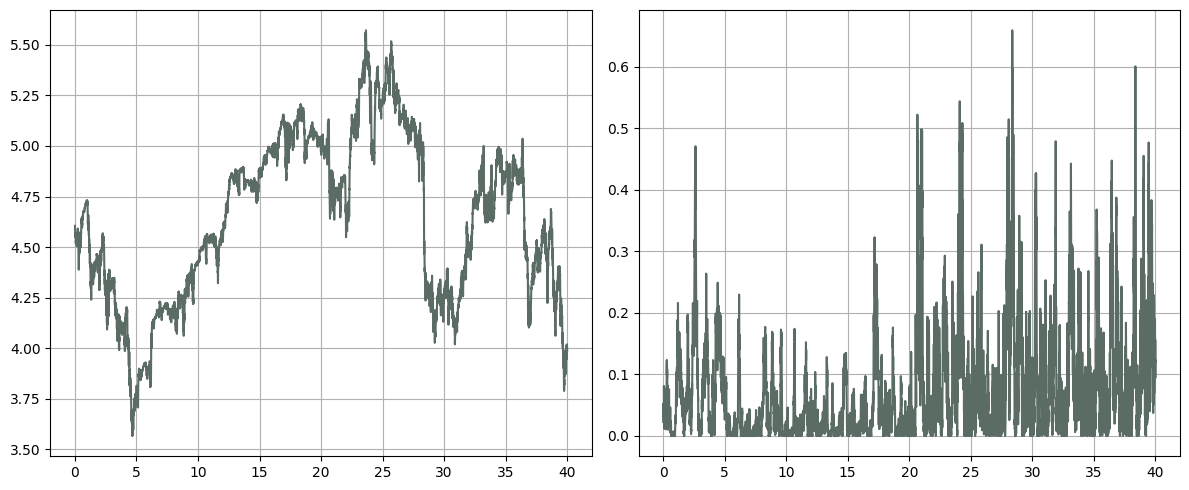

In [264]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(t_grid, np.log(S))
ax[1].plot(t_grid, V)

In [265]:
signal = np.log(S)

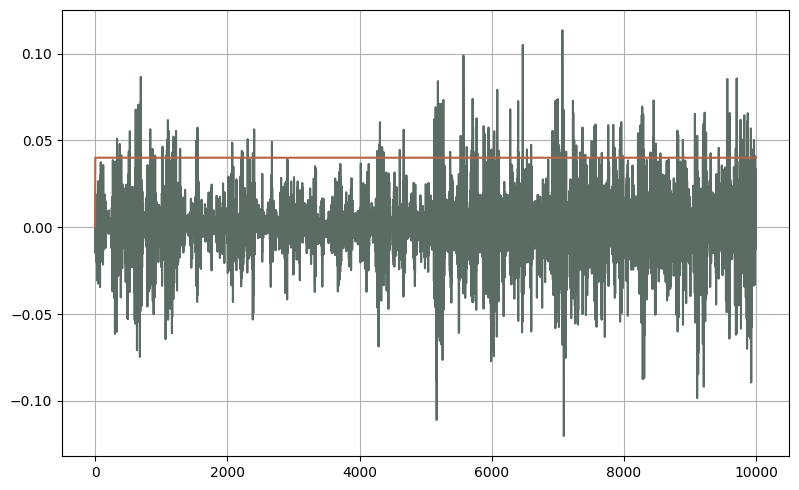

In [266]:
plt.plot(np.diff(signal, prepend=signal[0:1]))
plt.plot(np.diff(t_grid * 10, prepend=t_grid[0:1]))

(9999,) (9999,)


(-0.8430745480239162, 0.8430745480239162)

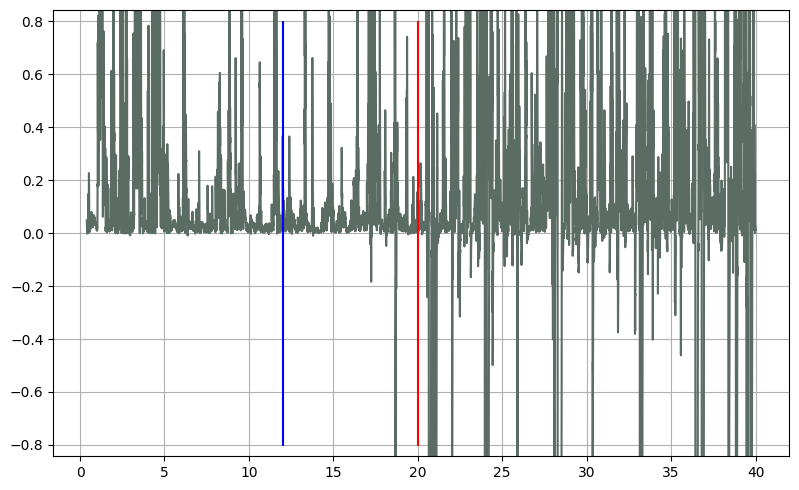

In [273]:
from sklearn.svm import OneClassSVM

# path = np.vstack((t_grid, t_grid, np.cumsum(signal) * np.diff(t_grid)[0])).T
print(t_grid.shape, signal.shape)
path = np.vstack((
    t_grid,
    t_grid * 10,
    signal,
    np.cumsum(np.diff(signal, prepend=signal[0:1])**2)
)).T

trunc = 4
N_train = int(len(t_grid_before) * 0.6)
lam_1 = 24 * 1
path_1 = path.copy()
path_1[:, 1:] = path_1[:, 1:] * lam_1
transformer_1 = EFMSignatureTransform(trunc=trunc, lam=lam_1)
pipe_1 = Pipeline([
    ('sig',transformer_1),
    ('scaler', StandardScaler()),
])
efm_sig_1 = pipe_1.fit_transform(path_1)

# Suppose 'ref_signatures' is a 2D array: (n_windows, signature_dimension)
# from your reference measure.

# 1. Initialize the model
# kernel='linear' is key because signatures linearize the space.
# nu=0.05 means we expect ~5% of reference data to be 'outliers'.
model = OneClassSVM(kernel='linear', nu=0.01)

# 2. Learn the reference regime (find theta and rho)
burn_in = 100
model.fit(X=efm_sig_1[burn_in:N_train])

# 3. Access the learned parameters
# In sklearn, 'coef_' is theta and 'intercept_' is -rho
theta = model.coef_
rho = -model.intercept_[0]

# 4. Use the model as your functional F(S_t)
# For a new signature S_t:
new_S_t = efm_sig_1

# decision_function(X) returns <theta, X> - rho
# This is exactly the functional we designed!
regime_score = model.decision_function(new_S_t)

plt.plot(t_grid[burn_in:], regime_score[burn_in:])

M = np.percentile(np.abs(regime_score), 90)
plt.vlines(t_grid_before[N_train], -M, M, label="EFM", color="blue")
plt.vlines(t_grid_before[-1], -M, M, label="CP", color="red")
plt.ylim([-1.05 * M, 1.05 * M])

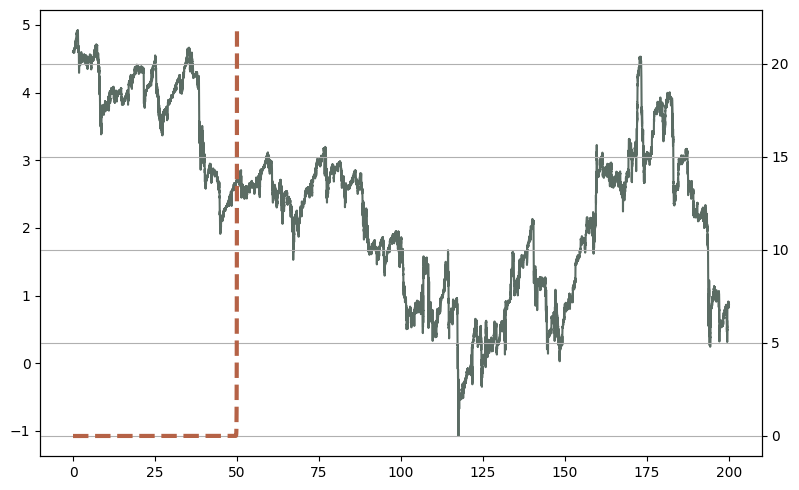

In [236]:
fig, ax = plt.subplots()
# 1. Create the twin axis for the exponential curves
ax_twin = ax.twinx()

# 2. Plot the signals on the original (left) y-axis
line1, = ax.plot(t_grid, signal, color=color_cycle[0], label='Signal')

# 3. Plot the exponential curves on the new (right) y-axis
# Added linestyle='--' to help distinguish theoretical curves from raw data
line3, = ax_twin.plot(t_grid[:N_train], lam_1 * np.exp(lam_1 * (t_grid[:N_train] - t_grid[N_train])),
                     color=color_cycle[1], linestyle='--', label='Fit 1', lw=3)
ax.grid(False)